# Bucketing vs True sim

In [370]:
import os
import sys
import itertools


def find_project_root(target_folder="masteroppgave"):
    """Find the absolute path of a folder by searching upward."""
    currentdir = os.path.abspath("__file__")  # Get absolute script path
    while True:
        if os.path.basename(currentdir) == target_folder:
            return currentdir  # Found the target folder
        parentdir = os.path.dirname(currentdir)
        if parentdir == currentdir:  # Stop at filesystem root
            return None
        currentdir = parentdir  # Move one level up

# Example usage
project_root = find_project_root("masteroppgave")

if project_root:
    sys.path.append(project_root)
    print(f"Project root found: {project_root}")
else:
    raise RuntimeError("Could not find 'masteroppgave' directory")

from utils.helpers.measure_similarities import *

Project root found: c:\Users\eivin\dev\masteroppgave


## Settings Grid

In [371]:
CITY = "rome"
BUCKETING_METHOD = "loose"
MEASURE = "dtw"
DATA_SIZE = 500
SCHEME = "grid"

## Read Runtime Bucketing and Merge with Bucket Evaluation

In [372]:
# Runtime bucketing
folder_path = f"../../results_hashed/runtimes/bucketing/{CITY}/true_trajectories/{BUCKETING_METHOD}/{MEASURE}/"
file_name = f"runtimes_bucketing({BUCKETING_METHOD})_(true_trajectories)_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}.csv"
file_path = folder_path + file_name

runtime_bucketing = pd.read_csv(file_path, index_col=0)

# Bucket evaluation
DATA_SIZE = 500
folder_path = f"../../results_hashed/bucket_evaluation/{BUCKETING_METHOD}/"
file_name = f"{CITY}_{MEASURE}_{SCHEME}_{DATA_SIZE}_{BUCKETING_METHOD}.csv"
file_path = folder_path + file_name

bucket_evaluation = pd.read_csv(file_path, index_col=0)

# Merge runtime bucketing and bucket evaluation dataframes on Resolution and Layers
bucket_evaluation_runtime_merged = pd.merge(bucket_evaluation, runtime_bucketing, on=["Resolution", "Layers", "Size", "Measure"], how="left")
bucket_evaluation_runtime_merged.head(5)


,Measure,Resolution,Layers,Size,Threshold,Avg Precision,Avg Recall,Avg F1 Score,Avg Number of buckets,Avg Bucket size,Avg Buckets with >1 Trajectory,Avg Largest Bucket Size,Avg Correlation Coefficient,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
0,dtw,0.01,1,500,0.1,0.003,0.889,0.007,16169.458,1.598,4834.042,16.333,0.798,15.863,11.767,0.053,27.683
1,dtw,0.01,1,500,0.2,0.021,0.811,0.040,16169.458,1.598,4834.042,16.333,0.798,15.863,11.767,0.053,27.683
2,dtw,0.01,1,500,0.3,0.054,0.713,0.100,16169.458,1.598,4834.042,16.333,0.798,15.863,11.767,0.053,27.683
3,dtw,0.01,1,500,0.4,0.097,0.637,0.168,16169.458,1.598,4834.042,16.333,0.798,15.863,11.767,0.053,27.683
4,dtw,0.01,1,500,0.5,0.145,0.558,0.230,16169.458,1.598,4834.042,16.333,0.798,15.863,11.767,0.053,27.683


## Read Runtime True Sim

In [373]:

folder_path = f"../../results_true/runtimes/{CITY}/{MEASURE}/"
file_name = f"{CITY}_true_similarity_runtimes_true_{MEASURE}_cy.csv"
file_path = folder_path + file_name

runtime_true_sim = pd.read_csv(file_path)

runtime_true_sim = runtime_true_sim[runtime_true_sim["Data Size"] == 500]
runtime_true_sim.head(5)

,Data Size,Average Similarity Computation Time (Seconds)
9,500,122.898


## Filter out rows where recall = 1

In [374]:
# Filter for only rows with perfect recall
filtered = bucket_evaluation_runtime_merged[bucket_evaluation_runtime_merged["Avg Recall"] == 1]

# Now group by Threshold and get the row with the minimum Total time per group
fastest_per_threshold = (
    filtered.loc[filtered.groupby("Threshold")["Total time (Seconds)"].idxmin()]
    .sort_values("Threshold")
)

# Select and reorder the columns you care about
fastest_per_threshold = fastest_per_threshold[
    ["Threshold", "Resolution", "Layers", "Size", 
     "Avg Largest Bucket Size", 
     "Average Similarity Computation Time (Seconds)", 
     "Average Hash Generation Time (Seconds)", 
     "Average Bucket Distribution Time (Seconds)", 
     "Total time (Seconds)"]
]

# Display result
fastest_per_threshold

,Threshold,Resolution,Layers,Size,Avg Largest Bucket Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
40,0.1,0.03,1,500,48.167,32.021,1.698,0.195,33.914
66,0.2,0.04,2,500,66.958,39.464,2.612,0.079,42.155
222,0.3,0.12,1,500,126.458,45.239,0.652,0.023,45.914
313,0.4,0.50,3,500,169.000,65.253,0.500,0.022,65.775
344,0.5,1.00,1,500,246.000,74.686,0.163,0.004,74.853


# Disk

In [375]:
SCHEME = "disk"

In [376]:
# Runtime bucketing
folder_path = f"../../results_hashed/runtimes/bucketing/{CITY}/true_trajectories/{BUCKETING_METHOD}/{MEASURE}/"
file_name = f"runtimes_bucketing({BUCKETING_METHOD})_(true_trajectories)_{CITY}_{MEASURE}_{DATA_SIZE}_{SCHEME}.csv"
file_path = folder_path + file_name

runtime_bucketing = pd.read_csv(file_path, index_col=0)
runtime_bucketing.head(5)


# Bucket evaluation
DATA_SIZE = 500
folder_path = f"../../results_hashed/bucket_evaluation/{BUCKETING_METHOD}/"
file_name = f"{CITY}_{MEASURE}_{SCHEME}_{DATA_SIZE}_{BUCKETING_METHOD}.csv"
file_path = folder_path + file_name

bucket_evaluation = pd.read_csv(file_path, index_col=0)

# Merge runtime bucketing and bucket evaluation dataframes on Resolution and Layers
bucket_evaluation_runtime_merged_disk = pd.merge(bucket_evaluation, runtime_bucketing, on=["Measure", "Diameter", "Layers", "Disks", "Size"], how="left")
bucket_evaluation_runtime_merged_disk.head(5)


# Filter for only rows with perfect recall
filtered_disk = bucket_evaluation_runtime_merged_disk[bucket_evaluation_runtime_merged_disk["Avg Recall"] == 1]

# Now group by Threshold and get the row with the minimum Total time per group
fastest_per_threshold_disk = (
    filtered_disk.loc[filtered_disk.groupby("Threshold")["Total time (Seconds)"].idxmin()]
    .sort_values("Threshold")
)

# Select and reorder the columns you care about
fastest_per_threshold_disk = fastest_per_threshold_disk[
    ["Threshold", "Diameter", "Layers", "Disks", "Size", 
     "Avg Largest Bucket Size", 
     "Average Similarity Computation Time (Seconds)", 
     "Average Hash Generation Time (Seconds)", 
     "Average Bucket Distribution Time (Seconds)", 
     "Total time (Seconds)"]
]

# Display result
fastest_per_threshold_disk



# print(bucket_evaluation_runtime_merged_disk.iloc[609])

,Threshold,Diameter,Layers,Disks,Size,Avg Largest Bucket Size,Average Similarity Computation Time (Seconds),Average Hash Generation Time (Seconds),Average Bucket Distribution Time (Seconds),Total time (Seconds)
100,0.1,0.2,3,200,500,106.583,30.710,1.457,0.202,32.369
151,0.2,0.3,2,400,500,130.250,44.647,0.904,0.437,45.988
172,0.3,0.3,3,400,500,146.625,48.977,1.332,0.672,50.981
338,0.4,0.8,1,250,500,185.000,64.659,0.525,0.412,65.596
384,0.5,0.8,3,200,500,187.250,71.589,1.398,0.987,73.974


In [377]:
best_runtimes_per_threshold_disk = fastest_per_threshold_disk["Total time (Seconds)"].tolist()

best_runtimes_per_threshold_grid = fastest_per_threshold["Total time (Seconds)"].tolist()

runtime_true_sim = runtime_true_sim["Average Similarity Computation Time (Seconds)"].tolist()

# Ensure runtime_true_sim is repeated to match thresholds
runtime_true_sim_repeated = [runtime_true_sim[0]] * 5

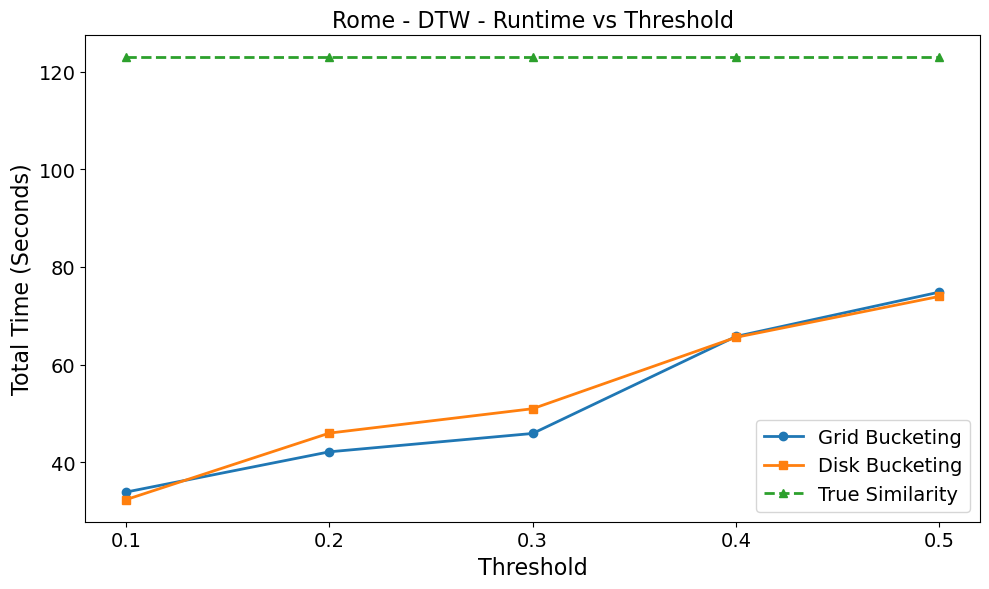

In [378]:
import matplotlib.pyplot as plt

def plot_runtime_per_threshold(
    disk_runtimes,
    grid_runtimes,
    true_sim_runtimes,
    thresholds=[0.1, 0.2, 0.3, 0.4, 0.5],
    city="Porto",
    measure="dtw"
):
    """
    Plots total runtimes (Disk, Grid, True Sim) for each threshold value.
    """
    fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

    ax.plot(thresholds, grid_runtimes, marker='o', linewidth=2, label='Grid Bucketing')
    ax.plot(thresholds, disk_runtimes, marker='s', linewidth=2, label='Disk Bucketing')
    ax.plot(thresholds, true_sim_runtimes, marker='^', linewidth=2, linestyle='--', label='True Similarity')

    ax.set_xlabel("Threshold", fontsize=16)
    ax.set_ylabel("Total Time (Seconds)", fontsize=16)
    ax.set_title(f"{city.capitalize()} - {measure.upper()} - Runtime vs Threshold", fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.grid(False)
    ax.legend(fontsize=14)
    # After ax1.plot(...) and before fig.tight_layout():
    ax.set_xticks(thresholds)

    fig.tight_layout()
    plt.show()

plot_runtime_per_threshold(
    disk_runtimes=best_runtimes_per_threshold_disk,
    grid_runtimes=best_runtimes_per_threshold_grid,
    true_sim_runtimes=runtime_true_sim_repeated,
    city=CITY,
    measure="dtw"
)

